In [8]:
# 1.  gdown
!pip install gdown -q


!gdown --folder https://drive.google.com/drive/folders/15c8YvUgBjQC_eRLhDs-2VbipdAVslYgc?usp=drive_link -O /kaggle/working/BigDataData


!ls /kaggle/working/BigDataData

Retrieving folder contents
Processing file 1ldYKNV_2NGluruZAj0sbdjQwiUFno4r6 climate_tensors_2014.tar.gz
Processing file 1A1BI8vE1UXskBItQSVcA-9Zbtm1IAc2A climate_tensors_2015.tar.gz
Processing file 163-PaUUFQ1Ox4YH8g05rgEKJTeqtzgKR climate_tensors_2016.tar.gz
Processing file 1YnWk33Ee4saV3DebfoOQDrsLWfkwy9Z_ climate_tensors_2017.tar.gz
Processing file 1nYiQuVFe09cALUA8eYjOZVXwzrSzbCzB climate_tensors_2018.tar.gz
Processing file 1mdzrafZSklT_04fU0FGgH-wgJwFstn0k climate_tensors_2019.tar.gz
Processing file 1f53OamTXKeqGw37nrV3zl7x9R6FX8mdo climate_tensors_2020.tar.gz
Processing file 1A3RB7bckiMYrK73ZCo464xKFOzTY1vnn climate_tensors_2021.tar.gz
Processing file 1kpP0qhk3HqMrTTLtc66zCDZMYAtWTOxQ climate_tensors_2022.tar.gz
Processing file 1eBP6q4L0puczfUCmihL8e0M4T3XsFU8J climate_tensors_2023.tar.gz
Processing file 1b18NSWlu_KkigBX3jj06yGts0pzCF20p climate_tensors_2024.tar.gz
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloadin

# Copy content

In [10]:
import os

In [7]:
!cp -r /content/drive/MyDrive/Data-sets/BigDataData $(pwd)

cp: cannot stat '/content/drive/MyDrive/Data-sets/BigDataData': No such file or directory


In [11]:
tar_list=sorted(os.listdir('BigDataData'))
tar_list

['climate_tensors_2014.tar.gz',
 'climate_tensors_2015.tar.gz',
 'climate_tensors_2016.tar.gz',
 'climate_tensors_2017.tar.gz',
 'climate_tensors_2018.tar.gz',
 'climate_tensors_2019.tar.gz',
 'climate_tensors_2020.tar.gz',
 'climate_tensors_2021.tar.gz',
 'climate_tensors_2022.tar.gz',
 'climate_tensors_2023.tar.gz',
 'climate_tensors_2024.tar.gz']

In [12]:
for tar_file in tar_list:
    print(f"Extracting {tar_file}...")
    !tar -xzvf BigDataData/{tar_file}


Extracting climate_tensors_2014.tar.gz...
y_2014.npy
scaler_params.npy
X_2014.npy
Extracting climate_tensors_2015.tar.gz...
X_2015.npy
y_2015.npy
scaler_params.npy
Extracting climate_tensors_2016.tar.gz...
scaler_params.npy
y_2016.npy
X_2016.npy
Extracting climate_tensors_2017.tar.gz...
X_2017.npy
y_2017.npy
scaler_params.npy
Extracting climate_tensors_2018.tar.gz...
y_2018.npy
scaler_params.npy
X_2018.npy
Extracting climate_tensors_2019.tar.gz...
y_2019.npy
scaler_params.npy
X_2019.npy
Extracting climate_tensors_2020.tar.gz...
y_2020.npy
scaler_params.npy
X_2020.npy
Extracting climate_tensors_2021.tar.gz...
scaler_params.npy
y_2021.npy
X_2021.npy
Extracting climate_tensors_2022.tar.gz...
scaler_params.npy
y_2022.npy
X_2022.npy
Extracting climate_tensors_2023.tar.gz...
X_2023.npy
scaler_params.npy
y_2023.npy
Extracting climate_tensors_2024.tar.gz...
scaler_params.npy
y_2024.npy
X_2024.npy


# Import Depencies

In [13]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader

# Model Architecture

## ConvLSTM cell arch.

In [15]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super(ConvLSTMCell, self).__init__()
        self.conv = nn.Conv2d(in_channels + out_channels, 4 * out_channels, kernel_size, padding=padding)

    def forward(self, x, state):
        h_prev, c_prev = state
        combined = torch.cat([x, h_prev], dim=1)
        gates = self.conv(combined)

        # Split gates: input, forget, cell, output
        i, f, g, o = torch.split(gates, gates.size(1) // 4, dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)

        c_next = f * c_prev + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next



## Model arch

In [16]:
class SpatioTemporalConvLSTM(nn.Module):
    def __init__(self, num_channels, hidden_dim, kernel_size,seq_len):
        super(SpatioTemporalConvLSTM, self).__init__()

        self.hidden_dim = hidden_dim

        # Layer 1: ConvLSTM + Batch Norm
        self.cell1 = ConvLSTMCell(num_channels, hidden_dim, kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(hidden_dim)

        # Layer 2: ConvLSTM + Batch Norm
        self.cell2 = ConvLSTMCell(hidden_dim, hidden_dim, kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm2d(hidden_dim)

        # Layer 3: Conv3D to collapse the sequence to a single prediction
        # (batch, hidden, sequence, lat, lon) -> (batch, 1, 1, lat, lon)
        self.conv_final = nn.Conv3d(hidden_dim, num_channels, kernel_size=(seq_len, 1, 1), padding=0)

    def forward(self, x):
        # x shape: (batch, time_steps, channels, lat, lon)
        b, t, c, h, w = x.size()

        # Initialize hidden states
        h1, c1 = torch.zeros(b, self.hidden_dim, h, w).to(x.device), torch.zeros(b, self.hidden_dim, h, w).to(x.device)
        h2, c2 = torch.zeros(b, self.hidden_dim, h, w).to(x.device), torch.zeros(b, self.hidden_dim, h, w).to(x.device)

        outputs = []
        for step in range(t):
            h1, c1 = self.cell1(x[:, step, :, :, :], (h1, c1))
            h1 = self.bn1(h1)

            h2, c2 = self.cell2(h1, (h2, c2))
            h2 = self.bn2(h2)
            outputs.append(h2.unsqueeze(2)) # Store sequence

        # Stack outputs: (batch, hidden, time_steps, lat, lon)
        output_seq = torch.cat(outputs, dim=2)

        # Collapse sequence to t+1 prediction
        prediction = self.conv_final(output_seq)
        return prediction.squeeze(2) # Final shape: (batch, channels, lat, lon)



# Getting Data Ready

- data is in tar files
- would be extracted as npy files
- model expects tensors in shape (batch,time steps,channels,lat,lon)
- Dataset class should take the x,y as npy, and the numpy files are pre extracted
- return tensor
- Dataloaders are straight forward

In [24]:
np_list = sorted([x for x in os.listdir() if x.endswith('.npy')])
np_list.pop(10)
np_list.pop(10)
np_list.pop(-1)

'y_2024.npy'

In [25]:
class TrainNumpyDataset(Dataset):
    def __init__(self, file_list):
        # Separate X and y files and sort them to ensure 2014, 2015... order
        self.x_files = sorted([f for f in file_list if f.startswith('X_')])
        self.y_files = sorted([f for f in file_list if f.startswith('y_')])

        # Defined boundaries based on your requirements (inclusive)
        # Each tuple: (start_idx, end_idx)
        self.boundaries = [
            (0, 350), (351, 701), (702, 1044), (1045, 1395),
            (1396, 1746), (1747, 2097), (2098, 2449), (2450, 2800),
            (2801, 3138), (3139, 3489)
        ]

        # Cache for loaded data to avoid repeated disk I/O (Optional)

    def __len__(self):
        # Returns the total count based on the final index provided
        return self.boundaries[-1][1] + 1

    def __getitem__(self, idx):
        # 1. Determine which "batch" (year) the index belongs to
        batch_idx = -1
        for i, (start, end) in enumerate(self.boundaries):
            if start <= idx <= end:
                batch_idx = i
                break

        if batch_idx == -1:
            raise IndexError(f"Index {idx} is out of range for the defined batches.")

        # 2. Load the corresponding year's .npy files
        # We use batch_idx to grab the correct file from our sorted lists
        x_data = np.load(self.x_files[batch_idx])
        y_data = np.load(self.y_files[batch_idx])

        # 3. Calculate the local index within that specific year's file
        # Local index = Global index - Start of that batch
        local_idx = idx - self.boundaries[batch_idx][0]

        # Ensure the local index doesn't exceed the actual numpy array size
        # (Useful if the boundary ranges don't perfectly match array lengths)
        local_idx = min(local_idx, len(x_data) - 1)

        x_sample = torch.from_numpy(x_data[local_idx])
        y_sample = torch.from_numpy(y_data[local_idx])

        x_sample = x_sample.permute(0, 3, 1, 2)  # → (time, channels, lat, lon) ✓
        y_sample = y_sample.permute(0,3,1,2)   # → (channels, lat, lon) ✓

        return x_sample, y_sample



In [26]:
class TrainNumpyDataset(Dataset):
    def __init__(self, file_list):
        self.x_files = sorted([f for f in file_list if f.startswith('X_')])
        self.y_files = sorted([f for f in file_list if f.startswith('y_')])

        self.boundaries = [
            (0, 350), (351, 701), (702, 1044), (1045, 1395),
            (1396, 1746), (1747, 2097), (2098, 2449), (2450, 2800),
            (2801, 3138), (3139, 3489)
        ]

        # --- CRITICAL UPDATE: Memory Mapping ---
        # We load references to the files in init, NOT the actual data.
        # mmap_mode='r' reads data directly from disk during __getitem__ without filling RAM.
        self.x_data_maps = [np.load(f, mmap_mode='r') for f in self.x_files]
        self.y_data_maps = [np.load(f, mmap_mode='r') for f in self.y_files]

    def __len__(self):
        return self.boundaries[-1][1] + 1

    def __getitem__(self, idx):
        batch_idx = -1
        for i, (start, end) in enumerate(self.boundaries):
            if start <= idx <= end:
                batch_idx = i
                break

        if batch_idx == -1:
            raise IndexError(f"Index {idx} is out of range.")

        local_idx = idx - self.boundaries[batch_idx][0]

        # Ensure we don't go out of bounds of the current file length
        max_len = len(self.x_data_maps[batch_idx]) - 1
        local_idx = min(local_idx, max_len)

        # Fetch ONLY the specific slice from disk, and convert to standard numpy array
        x_slice = np.array(self.x_data_maps[batch_idx][local_idx])
        y_slice = np.array(self.y_data_maps[batch_idx][local_idx])

        x_sample = torch.from_numpy(x_slice)
        y_sample = torch.from_numpy(y_slice)

        x_sample = x_sample.permute(0, 3, 1, 2)
        y_sample = y_sample.permute(0, 3, 1, 2)

        return x_sample, y_sample

In [38]:
dataset = TrainNumpyDataset(np_list)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

In [39]:
# Reduced batch_size to 2.
# Added num_workers and pin_memory to speed up the disk-to-GPU transfer.
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=2, pin_memory=True)

In [40]:
dataset[0][1].shape

torch.Size([1, 1, 200, 260])

In [41]:
np.load('//kaggle/working/y_2024.npy').shape

(352, 1, 200, 260, 1)

# Train Loop

## Configs

In [55]:
# --- Initialization and Compilation ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpatioTemporalConvLSTM(num_channels=1, hidden_dim=64, kernel_size=3,seq_len=14).to(device)

# Loss: Huber Loss as per specification
criterion = nn.SmoothL1Loss()

# Optimizer: AdamW with weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)

print(model)

SpatioTemporalConvLSTM(
  (cell1): ConvLSTMCell(
    (conv): Conv2d(65, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (cell2): ConvLSTMCell(
    (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_final): Conv3d(64, 1, kernel_size=(14, 1, 1), stride=(1, 1, 1))
)


In [57]:
device

device(type='cuda')

## Train Function

In [58]:
import torch
import gc
from tqdm import tqdm
from torch.amp import autocast, GradScaler 

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=25, accumulation_steps=16, device='cuda'):
    history = {'train': [], 'val': []}
    
    # Initialize the scaler for Mixed Precision (float16) training on CUDA
    scaler = GradScaler('cuda') 

    for epoch in range(num_epochs):
        # ==========================================
        # --- TRAINING PHASE ---
        # ==========================================
        model.train()
        running_loss = 0.0
        
        # Progress bar for the training loop
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        
        # Clear gradients at the start of the epoch
        optimizer.zero_grad() 

        for i, (inputs, labels) in enumerate(train_loop):
            # Move data to the specified device (GPU)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # --- [CRITICAL FIX] Clean data ---
            # Convert any NaN values in the data to 0.0 to prevent loss corruption
            inputs = torch.nan_to_num(inputs, nan=0.0)
            labels = torch.nan_to_num(labels, nan=0.0)

            # --- [CRITICAL FIX] Shape Mismatch ---
            # Squeeze extra empty dimension if labels shape is [batch, 1, 1, lat, lon]
            if labels.dim() == 5 and labels.size(2) == 1:
                labels = labels.squeeze(2)

            # Forward pass using Mixed Precision (autocast) to save VRAM
            with autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                # Normalize the loss to account for gradient accumulation
                loss = loss / accumulation_steps 

            # Backward pass using the scaler
            scaler.scale(loss).backward()

            # Update weights only after accumulating gradients for 'accumulation_steps'
            # or if it is the final batch in the dataloader
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                # Unscale gradients before clipping
                scaler.unscale_(optimizer)
                # Gradient Clipping: Prevent exploding gradients by capping them at 1.0
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                # Optimizer step and scaler update
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad() 

            # De-normalize the loss for accurate logging
            actual_loss = loss.item() * accumulation_steps
            running_loss += actual_loss * inputs.size(0)
            
            # Update the progress bar
            train_loop.set_postfix(loss=actual_loss)

        # Calculate average training loss for the epoch
        epoch_train_loss = running_loss / len(train_loader.dataset)

        # ==========================================
        # --- VALIDATION PHASE ---
        # ==========================================
        model.eval()
        running_val_loss = 0.0

        # Check if validation dataset is empty to avoid division by zero (NaN loss)
        if len(val_loader.dataset) == 0:
            print("\n🚨 WARNING: Validation dataset is empty! Please check your data split boundaries.")
            epoch_val_loss = float('nan')
        else:
            # Disable gradient calculation for validation to save memory
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # --- [CRITICAL FIX] Clean validation data ---
                    # Convert any NaN values to 0.0
                    inputs = torch.nan_to_num(inputs, nan=0.0)
                    labels = torch.nan_to_num(labels, nan=0.0)

                    # Apply the same shape correction to validation labels
                    if labels.dim() == 5 and labels.size(2) == 1:
                        labels = labels.squeeze(2)

                    # Use autocast during validation
                    with autocast('cuda'):
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        
                    running_val_loss += loss.item() * inputs.size(0)

            # Calculate average validation loss for the epoch
            epoch_val_loss = running_val_loss / len(val_loader.dataset)
        
        # ==========================================
        # --- EPOCH WRAP-UP ---
        # ==========================================
        
        # Step the learning rate scheduler based on validation loss
        scheduler.step(epoch_val_loss)

        # Save the metrics for plotting later
        history['train'].append(epoch_train_loss)
        history['val'].append(epoch_val_loss)

        # Print epoch summary
        print(f"\nEpoch {epoch+1} Summary: Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

        # Force memory cleanup at the end of each epoch to prevent VRAM fragmentation
        torch.cuda.empty_cache()
        gc.collect()

    return history

In [59]:
results = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,  accumulation_steps=16, device=device)

Epoch 1/25 [Train]: 100%|██████████| 1396/1396 [14:06<00:00,  1.65it/s, loss=0.235] 



Epoch 1 Summary: Train Loss: 0.1936 | Val Loss: 0.1084


Epoch 2/25 [Train]: 100%|██████████| 1396/1396 [13:41<00:00,  1.70it/s, loss=0.0342]



Epoch 2 Summary: Train Loss: 0.1366 | Val Loss: 0.0502


Epoch 3/25 [Train]: 100%|██████████| 1396/1396 [13:40<00:00,  1.70it/s, loss=0.0082] 


...


Epoch 21 Summary: Train Loss: 0.0053 | Val Loss: 0.0138


Epoch 22/25 [Train]: 100%|██████████| 1396/1396 [13:47<00:00,  1.69it/s, loss=0.00251] 



Epoch 22 Summary: Train Loss: 0.0053 | Val Loss: 0.0375


Epoch 23/25 [Train]: 100%|██████████| 1396/1396 [13:39<00:00,  1.70it/s, loss=0.00218] 


KeyboardInterrupt: 

#
---

0 -> 350 = first batch  
351 -> 701 = second batch  
702 -> 1044 = third Batch  
1045 -> 1395 = fourth batch  
1396 -> 1746 = fifth batch  
1747 -> 2097 = sixth batch  
2098 -> 2449 = seventh batch  
2450 -> 2800 = eighth batch  
2801 -> 3138 = ninth batch  
3139 -> 3489 = tenth batch  
3490 -> 3841 = last batch  


## save model and history

In [61]:
import torch

# 1. Define the save path in Kaggle's working directory
# Note: Everything in /kaggle/working/ is available for download after the session
model_save_path = '/kaggle/working/climate_convlstm_best.pth'

# 2. Save the model weights (state_dict)
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully at: {model_save_path}")

Model saved successfully at: /kaggle/working/climate_convlstm_best.pth


In [71]:
import json
from IPython.display import FileLink, display


manual_history = {
    'train': [
        0.1936, 0.1366, 0.0605, 0.0160, 0.0066, 0.0062, 0.0057, 0.0055, 
        0.0055, 0.0053, 0.0054, 0.0054, 0.0052, 0.0053, 0.0053, 0.0053, 
        0.0054, 0.0054, 0.0054, 0.0053, 0.0053, 0.0053
    ],
    'val': [
        0.1084, 0.0502, 0.0081, 0.0157, 0.0197, 0.0241, 0.0236, 0.0179, 
        0.0262, 0.0333, 0.0372, 0.0269, 0.0217, 0.0243, 0.0152, 0.0357, 
        0.0521, 0.0444, 0.0383, 0.0160, 0.0138, 0.0375
    ]
}

# 2. حفظ الداتا في ملف JSON
with open('/kaggle/working/training_history.json', 'w') as f:
    json.dump(manual_history, f)


# 3. رابط التحميل
display(FileLink('training_history.json'))

/kaggle/working/training_history.json

## plots

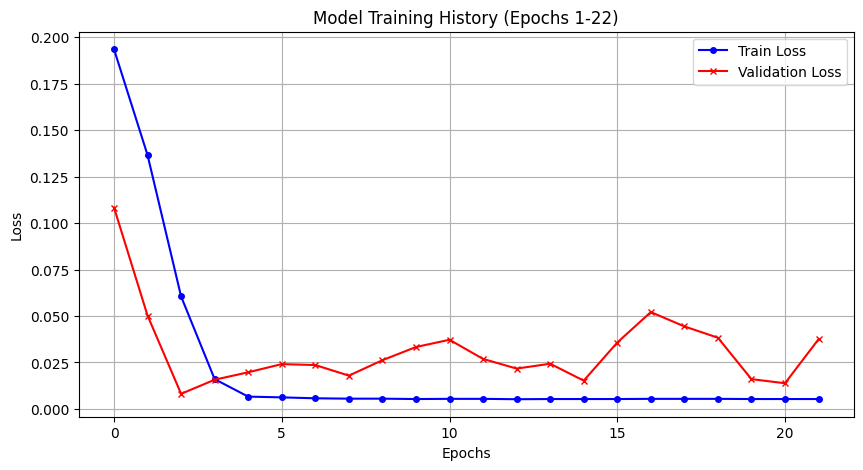

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(manual_history['train'], label='Train Loss', color='blue', marker='o', markersize=4)
plt.plot(manual_history['val'], label='Validation Loss', color='red', marker='x', markersize=4)

plt.title('Model Training History (Epochs 1-22)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

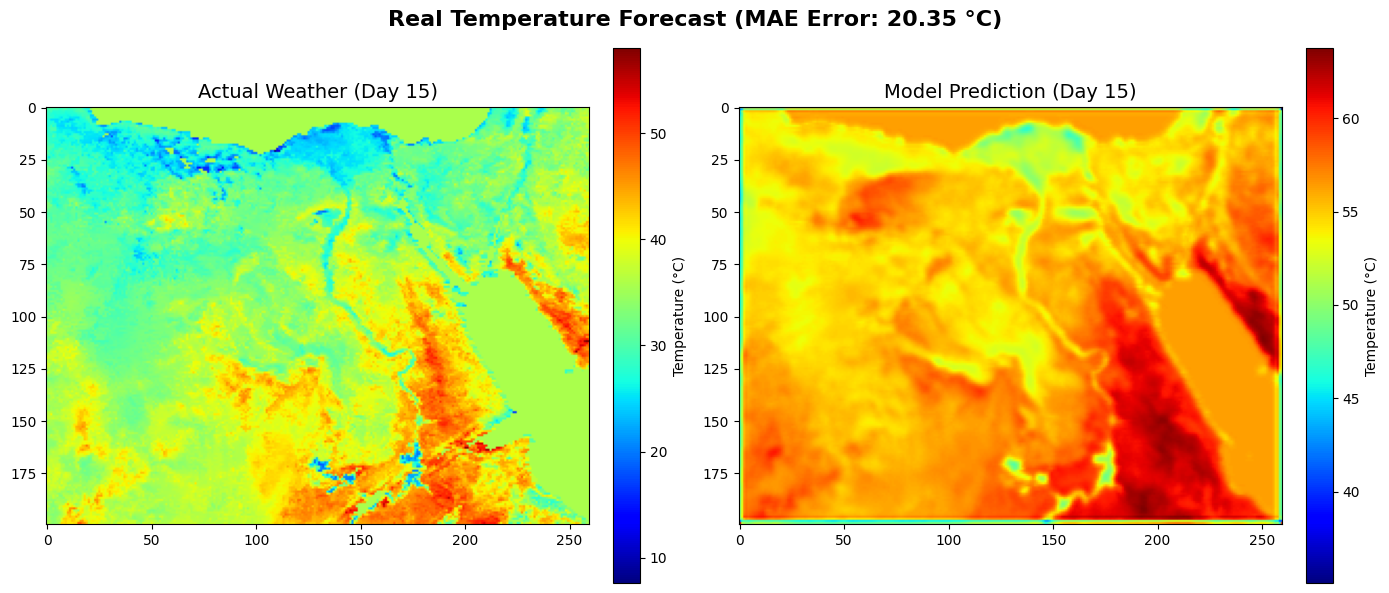

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Load Scaler Parameters
# ==========================================
try:
    scaler_params = np.load('/kaggle/working/scaler_params.npy', allow_pickle=True).item()
    temp_min = scaler_params['min']
    temp_max = scaler_params['max']
except Exception as e:
    scaler_params = np.load('/kaggle/working/scaler_params.npy')
    temp_min = scaler_params[0]
    temp_max = scaler_params[1]

# ==========================================
# 2. Inverse Transform and Convert to Celsius
# ==========================================
def inverse_transform_to_celsius(scaled_data, t_min, t_max):
    # First, revert the Min-Max scaling back to original Kelvin values
    kelvin_temp = (scaled_data * (t_max - t_min)) + t_min
    # Then, convert Kelvin to Celsius
    celsius_temp = kelvin_temp - 273.15 
    return celsius_temp

real_map_actual_c = inverse_transform_to_celsius(map_actual, temp_min, temp_max)
real_map_predicted_c = inverse_transform_to_celsius(map_predicted, temp_min, temp_max)

# ==========================================
# 3. Calculate Error in Celsius
# ==========================================
mae_celsius = np.mean(np.abs(real_map_actual_c - real_map_predicted_c))

# ==========================================
# 4. Plot the Maps
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(real_map_actual_c, cmap='jet')
axes[0].set_title("Actual Weather (Day 15)", fontsize=14)
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Temperature (°C)')

im2 = axes[1].imshow(real_map_predicted_c, cmap='jet')
axes[1].set_title("Model Prediction (Day 15)", fontsize=14)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Temperature (°C)')

plt.suptitle(f"Real Temperature Forecast (MAE Error: {mae_celsius:.2f} °C)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()